I will train a model so that we get better readings on the players than what was previously inferenced

Imports

imports are placed here but once again we have that _patched_torch_load() function here to set that weights_only=False for that pickling error we were getting with pytorch since they changed the default of weights_only=True

In [3]:
# Fix for PyTorch 2.6: Patch torch.load to allow YOLO model loading
import torch
import torch.serialization

# Store original torch.load
_original_torch_load = torch.load

# Create a wrapper that sets weights_only=False for YOLO model files
def _patched_torch_load(f, map_location=None, pickle_module=None, weights_only=None, **kwargs):
    # Always set weights_only=False for YOLO compatibility
    # This allows loading custom YOLO classes that aren't in safe globals
    weights_only = False
    return _original_torch_load(f, map_location=map_location, pickle_module=pickle_module, weights_only=weights_only, **kwargs)

# Patch torch.load
torch.load = _patched_torch_load

from ultralytics import YOLO

Checking if GPU is being used

We want to make sure we are using the GPU and not the CPU. In the case of us having multiple GPUs we want to make sure we are using the right one. This is something I had CLAUDE help me type up so that I could make sure it wasnt my CPU being used 

In [ ]:
# Check PyTorch CUDA availability
print("=" * 50)
print("GPU/Device Check")
print("=" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"Current device: cuda:0")
    print("✅ GPU is available and will be used for training!")
else:
    print("Current device: CPU")
    print("⚠️  WARNING: Using CPU - training will be much slower!")
    print("💡 Tip: Make sure you have CUDA-enabled PyTorch installed if you have an NVIDIA GPU")

print("\n" + "=" * 50)
print("Ultralytics YOLO Device Check")
print("=" * 50)
# Check what device YOLO will use
try:
    model_check = YOLO("yolov8n.pt")
    device = next(model_check.model.parameters()).device
    print(f"YOLO model device: {device}")
    if str(device) == "cpu":
        print("⚠️  YOLO is using CPU - check if GPU is properly configured")
    else:
        print(f"✅ YOLO will use: {device}")
except Exception as e:
    print(f"⚠️  Could not check YOLO device: {e}")
print("=" * 50)


Loading and training the model

Here we are fine tuning that base yolov8n.pt model we inferenced previously. We have our own dataset we are using for the fine tune. I am going to explain all the hyperparameters for the train:

epochs = 100: this is how many times are we looping through the data in training it. A good analogy is a count for how many times you reread lecture before you walked into the exam. The epoch is basically how many times it reread your data before it ended its studying

patience = 15: we want to end the train early if we arent seeing improvement. The patience is to stop if we dont see noticeable improvements for 15 epochs. We dont want to overfit our model

lr0=0.001: This is really important. The learning rate is basically, after every epoch how much do we want to increase or decrease the weights to get to the lowest loss function. The learning rate value is how much we trust how much the gradient calculation says we need to increase or decrease the weight. So if the gradient said, increase the weight of this feature by 5, the learning rate0 would do .001*5 = .05 is how much we are actually going to increase the weight. We normally want learning rate to be higher in lower epochs and higher as we get higher in our epochs. somethings a learning rate scheduler is used to do that. 

device=0: we are setting which device (cpu or different gpus) for this. setting to 0 is us using our GPU

batch = 16: The gradient is averaged over the batch size and then after each batch size (16 in our case) it tells the model how much to alter its weights to try and reach the point where the loss function is lowest. Remember, that if its over a smaller batch will allow for more weight updates per epoch which will allow it to bypass local minima

pretrained=true: uses pretrained weights which is something we want to do because we want to use it as a base

optimizer = AdamW

In [4]:
# Load pre-trained COCO model for fine-tuning
model = YOLO("yolov8n.pt")

# Fine-tune on custom dataset
# Key parameters for fine-tuning:
# - lr0: Lower learning rate for fine-tuning (0.001 is good, default 0.01 is for training from scratch)
# - device: Explicitly set to use GPU (0) or CPU
# - batch: Adjust based on GPU memory (16 is default, reduce if OOM errors)
# - epochs: Number of training epochs
# - patience: Early stopping patience
# - imgsz: Image size (640 is standard)
results = model.train(
    data="Training_Dataset/data.yaml",
    epochs=100,
    imgsz=640,
    patience=15,
    lr0=0.001,  # Lower learning rate for fine-tuning (10x smaller than default)
    device=0,   # Use GPU 0 (set to 'cpu' if no GPU, or None for auto-detect)
    batch=16,   # Adjust based on GPU memory (reduce if out of memory)
    pretrained=True,  # Use pre-trained weights (default, but explicit is good)
    optimizer='AdamW',  # AdamW often works better for fine-tuning than SGD
    val=True,   # Validate during training
    plots=True, # Generate training plots
    save=True,  # Save checkpoints
)

New https://pypi.org/project/ultralytics/8.3.234 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.47  Python-3.12.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 with Max-Q Design, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=Training_Dataset/data.yaml, epochs=100, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train64, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

C:\Users\Guest1\.ultralytics\ultralytics\utils\checks.py:640: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
C:\Users\Guest1\.ultralytics\ultralytics\engine\trainer.py:261: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
train: Scanning C:\Object_Detection_Projects\Soccer_AI\Training_Dataset\train\labels.cache... 612 images, 0 backgrounds, 0 corrupt: 100%|██████████| 612/612 [00:00<?, ?it/s]
val: Scanning C:\Object_Detection_Projects\Soccer_AI\Training_Dataset\valid\labels.cache... 38 images, 0 backgrounds, 0 corrupt: 100%|██████████| 38/38 [00:00<?, ?it/s]


Plotting labels to C:\Users\Guest1\Documents\YoloObjectID\ultralytics\runs\detect\train64\labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Guest1\Documents\YoloObjectID\ultralytics\runs\detect\train64
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/100      3.47G      1.794      2.476     0.8984        144        640: 100%|██████████| 39/39 [00:08<00:00,  4.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.84it/s]

                   all         38        905    0.00869      0.131     0.0677     0.0158


...

     97/100      2.28G     0.8371     0.4085     0.7865         93        640: 100%|██████████| 39/39 [00:24<00:00,  1.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.62it/s]

                   all         38        905      0.837      0.642       0.72      0.463


EarlyStopping: Training stopped early as no improvement observed in last 15 epochs. Best results observed at epoch 82, best model saved as best.pt.
To update EarlyStopping(patience=15) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

97 epochs completed in 0.491 hours.
Optimizer stripped from C:\Users\Guest1\Documents\YoloObjectID\ultralytics\runs\detect\train64\weights\last.pt, 6.2MB
Optimizer stripped from C:\Users\Guest1\Documents\YoloObjectID\ultralytics\runs\detect\train64\weights\best.pt, 6.2MB

Validating C:\Users\Guest1\Documents\YoloObjectID\ultralytics\runs\detect\train64\weights\best.pt...
Ultralytics YOLOv8.1.47  Python-3.12.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 with Max-Q Design, 8192MiB)
Model summary (fused): 168 layers, 3006428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.06it/s]


                   all         38        905      0.875       0.69      0.753       0.48
                  ball         38         35      0.893      0.143      0.238     0.0463
            goalkeeper         38         27      0.856      0.881      0.944      0.646
                player         38        754      0.934      0.948      0.978      0.717
               referee         38         89      0.817      0.787      0.851      0.509
Speed: 0.7ms preprocess, 9.4ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to C:\Users\Guest1\Documents\YoloObjectID\ultralytics\runs\detect\train64


After finishing the training I want to analyze the training results. First I'm going to take a look at some of the curve graphs

Normalized Confusion Matrix: 
a-Looks like the main thing that is reducing the precision is mixing up the background with the true object being detected.
b-Looks like the recall is pretty good 

F1 Curve - the f1 curve shows the harmonic mean between the recall and the precision. The confidence shows us the confidence score for the detected object. We can see that the f1 curve is at its highest for all classes around .3 confidence score. So that is the optimal confidence score. When we set our confidence score we will most likely set it to that

Seeing what directory we are inside

In [5]:
import os
print(os.getcwd())


c:\Object_Detection_Projects\Soccer_AI


After training the model lets see if it is able to recognize the picture better



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 1 goalkeeper, 19 players, 3 referees, 32.0ms
video 1/1 (frame 2/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 1 goalkeeper, 19 players, 3 referees, 13.0ms
video 1/1 (frame 3/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 1 goalkeeper, 20 players, 3 referees, 14.0ms
video 1/1 (frame 4/750) c:\Ob

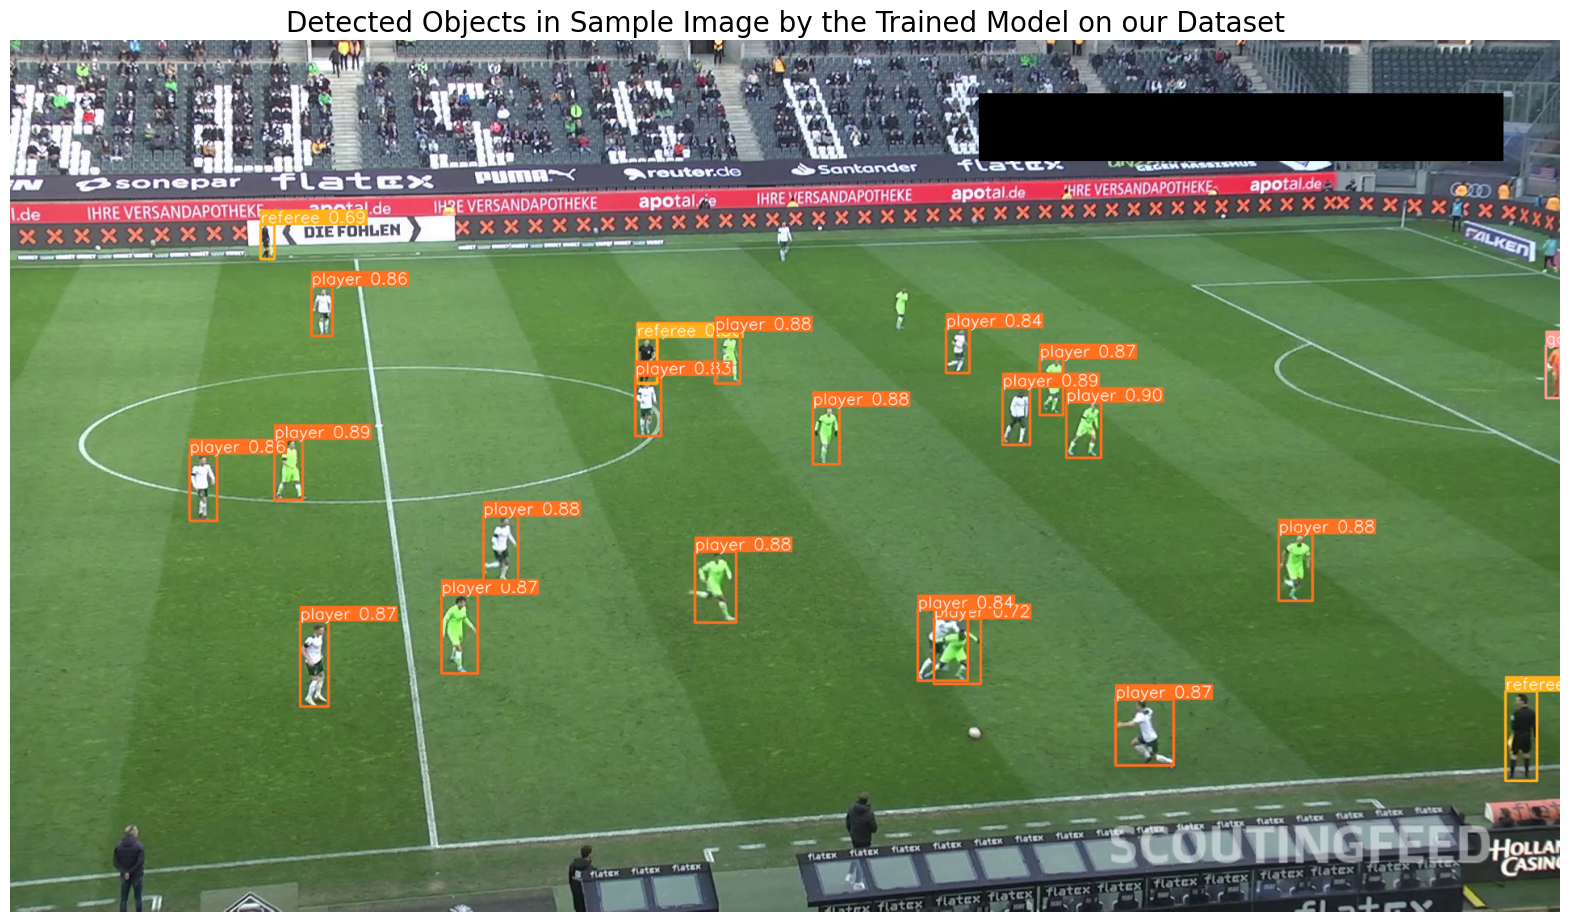

In [9]:
import cv2
import matplotlib.pyplot as plt

model = YOLO("train64/weights/best.pt")
result = model.predict("input-videos/08fd33_4.mp4", stream=False, save=True, save_dir="inference_results/trained_inference/")

sample_image = result[0].plot(line_width=2)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_RGB2BGR)

# Display annotated image
plt.figure(figsize=(20,15))
plt.imshow(sample_image)
plt.title('Detected Objects in Sample Image by the Trained Model on our Dataset', fontsize=20)
plt.axis('off')
plt.show() # save to disk